# lob-engine: replay, signal and P&L

Analysis of five Nasdaq trading days (LOBSTER samples, 2012-06-21) using the `lob` Python
module, which wraps the C++ order book, replay and backtester.

Setup, from the repository root:

```
pip install ".[notebook]"
scripts/download_data.sh
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import lob

DATA = next(p for p in [Path("data"), Path("../data")] if p.exists())
TICKERS = ["AAPL", "AMZN", "GOOG", "INTC", "MSFT"]
MORNING = (34_200, 45_900)    # 09:30 to 12:45, seconds after midnight
AFTERNOON = (45_900, 57_600)  # 12:45 to 16:00
TICK = 0.01

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})


def load_day(ticker):
    stem = DATA / f"{ticker}_2012-06-21_34200000_57600000"
    return lob.Day(f"{stem}_message_10.csv", f"{stem}_orderbook_10.csv")


def clock(seconds):
    """Seconds after midnight -> hours, for time axes."""
    return np.asarray(seconds) / 3600

## 1. The replay is exact

Each day is replayed message by message and the book is compared with LOBSTER's recorded top
10 levels after every message. `mismatches` counts rows where any level inside the reported
window differs. `revealed` counts levels that came into view from beyond the 10-level window,
where LOBSTER reports no events.

In [2]:
rows = []
days_signal = {}
for ticker in TICKERS:
    day = load_day(ticker)
    r = day.replay("ladder")
    rows.append({"stock": ticker, "checked rows": r["messages"] - 1, "mismatches": r["mismatches"],
                 "exact rows": r["exact_rows"], "pre-existing ids": r["unknown_ids"],
                 "revealed": r["revealed_levels"]})
    days_signal[ticker] = pd.DataFrame(day.signal(levels=3))
    del day

replay = pd.DataFrame(rows).set_index("stock")
replay.loc["total"] = replay.sum()
replay["exact %"] = 100 * replay["exact rows"] / replay["checked rows"]
replay.style.format("{:,.0f}").format({"exact %": "{:.1f}"})

,checked rows,mismatches,exact rows,pre-existing ids,revealed,exact %
stock,,,,,,
AAPL,400390,0,385219,16984,104562,96.2
AMZN,269747,0,259146,12788,52189,96.1
GOOG,147915,0,141636,7120,44451,95.8
INTC,624039,0,623049,3888,1645,99.8
MSFT,668764,0,667314,4558,2042,99.8
total,2110855,0,2076364,45338,204889,98.4


## 2. The book over time

AAPL across the whole day, then a two-minute window of the replayed book's top 10 levels. Each
dot is a resting price level, darker for more shares.

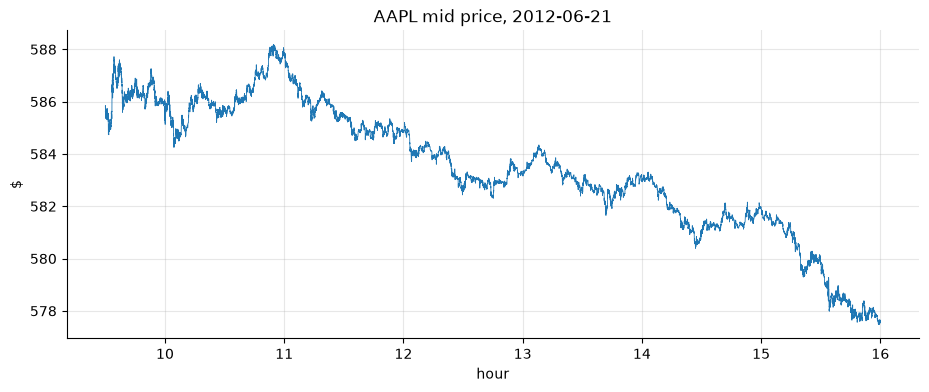

In [3]:
sig = days_signal["AAPL"]
fig, ax = plt.subplots()
ax.plot(clock(sig["time"]), sig["mid"], lw=0.6, color="tab:blue")
ax.set(title="AAPL mid price, 2012-06-21", xlabel="hour", ylabel="$")
plt.show()

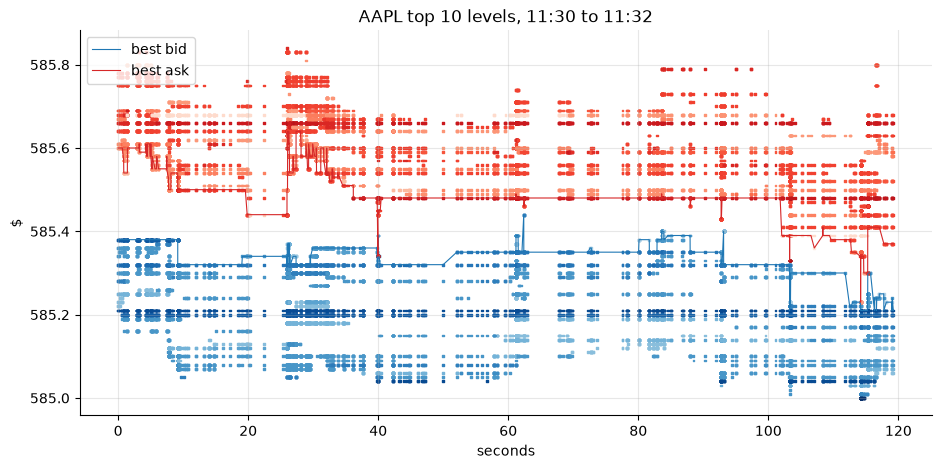

In [4]:
day = load_day("AAPL")
book = day.book_history(levels=10, step=1)
del day

start, end = 41_400, 41_520  # 11:30:00 to 11:32:00
window = (book["time"] >= start) & (book["time"] < end)
t = book["time"][window] - start

fig, ax = plt.subplots(figsize=(11, 5))
for side, cmap in [("bid", "Blues"), ("ask", "Reds")]:
    price = book[f"{side}_price"][window]
    size = book[f"{side}_size"][window]
    times = np.repeat(t[:, None], price.shape[1], axis=1)
    shown = ~np.isnan(price)
    ax.scatter(times[shown], price[shown], c=np.log1p(size[shown]), cmap=cmap, s=2, marker="s",
               vmin=0, vmax=np.log1p(2000))
ax.plot(t, book["bid_price"][window, 0], color="tab:blue", lw=0.8, label="best bid")
ax.plot(t, book["ask_price"][window, 0], color="tab:red", lw=0.8, label="best ask")
ax.set(title="AAPL top 10 levels, 11:30 to 11:32", xlabel="seconds", ylabel="$")
ax.legend(loc="upper left")
plt.show()

## 3. Does imbalance predict the next price move?

Imbalance = (bid volume − ask volume) / (bid volume + ask volume) over the top 3 levels,
sampled at every book update. The left panel bins it into deciles and shows the average *next*
mid-price change, in ticks. The right panel shows how the correlation with the mid-price change
decays as the horizon grows.

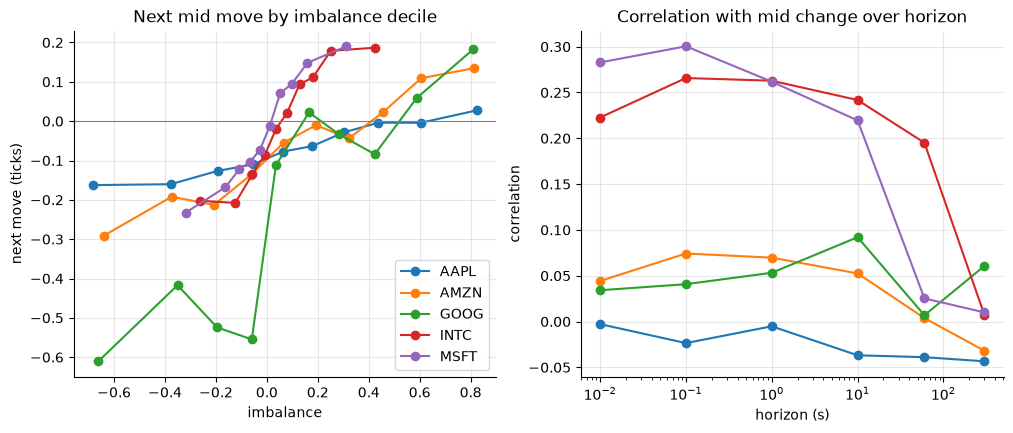

,next move,0.01 s,0.1 s,1 s,10 s,60 s,300 s
stock,,,,,,,
AAPL,0.025,-0.003,-0.024,-0.005,-0.037,-0.039,-0.043
AMZN,0.064,0.044,0.074,0.070,0.053,0.004,-0.032
GOOG,0.047,0.034,0.041,0.053,0.092,0.007,0.061
INTC,0.260,0.223,0.266,0.263,0.242,0.195,0.007
MSFT,0.242,0.283,0.300,0.262,0.219,0.025,0.010


In [5]:
def next_move(mid):
    """Change to the next different mid price after each sample (NaN if none)."""
    mid = np.asarray(mid)
    starts = np.flatnonzero(np.diff(mid) != 0) + 1          # where a new mid begins
    k = np.searchsorted(starts, np.arange(len(mid)), side="right")
    move = np.full(len(mid), np.nan)
    has_next = k < len(starts)
    move[has_next] = mid[starts[k[has_next]]] - mid[has_next]
    return move


def move_after(time, mid, horizon):
    """Mid change over the next `horizon` seconds (NaN past the end of the day)."""
    time, mid = np.asarray(time), np.asarray(mid)
    j = np.searchsorted(time, time + horizon, side="right") - 1
    move = mid[j] - mid
    move[time + horizon > time[-1]] = np.nan
    return move


horizons = [0.01, 0.1, 1, 10, 60, 300]
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.5))
corr_rows = []
for ticker in TICKERS:
    time, imb, mid = (days_signal[ticker][c].to_numpy() for c in ["time", "imbalance", "mid"])
    move = next_move(mid) / TICK
    ok = ~np.isnan(move)
    decile = pd.qcut(imb[ok], 10, labels=False, duplicates="drop")
    centers = pd.Series(imb[ok]).groupby(decile).mean()
    binned = pd.Series(move[ok]).groupby(decile).mean()
    left.plot(centers, binned, marker="o", label=ticker)

    corrs = []
    for h in horizons:
        m = move_after(time, mid, h)
        good = ~np.isnan(m)
        corrs.append(np.corrcoef(imb[good], m[good])[0, 1])
    right.plot(horizons, corrs, marker="o", label=ticker)
    corr_rows.append({"stock": ticker, "next move": np.corrcoef(imb[ok], move[ok])[0, 1],
                      **{f"{h:g} s": c for h, c in zip(horizons, corrs)}})

left.axhline(0, color="grey", lw=0.8)
left.set(title="Next mid move by imbalance decile", xlabel="imbalance", ylabel="next move (ticks)")
right.set(title="Correlation with mid change over horizon", xlabel="horizon (s)", xscale="log",
          ylabel="correlation")
left.legend()
plt.show()
pd.DataFrame(corr_rows).set_index("stock").style.format("{:.3f}")

Higher imbalance means a higher next move on every stock. The effect is strongest on INTC and
MSFT (correlation 0.24 to 0.26), whose prices are low relative to the one-cent tick: their queues
are deep, so queue sizes carry information. On the high-priced stocks it is weak (0.03 to 0.06),
and GOOG's deciles are noisy.

Over longer horizons the correlation fades: INTC holds up to about a minute and MSFT to about
10 seconds. On AAPL it even turns slightly negative beyond the next tick. Imbalance says where
the next tick goes, not where the price will be in a minute.

## 4. Trading it: P&L after costs

The strategy crosses the spread when |imbalance| ≥ threshold, trades 100 shares and exits after
a fixed holding time, with 50 µs latency and a $0.003/share fee. The threshold and holding time
are chosen on the **morning** (best net P&L with at least 20 trades). That one setting is then
run on the **afternoon**.

In [6]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
holdings = [0.1, 0.5, 1, 5, 10, 30, 60]
MIN_TRADES = 20

results, curves = [], {}
for ticker in TICKERS:
    day = load_day(ticker)
    grid = pd.DataFrame(day.backtest_grid(thresholds, holdings, *MORNING))
    best = grid[grid["trades"] >= MIN_TRADES].sort_values("net", ascending=False).iloc[0]
    test = day.backtest(best["threshold"], best["holding_s"], *AFTERNOON)
    del day

    for half, summary in [("morning", best), ("afternoon", test["summary"])]:
        results.append({"stock": ticker, "half": half, "threshold": best["threshold"],
                        "holding s": best["holding_s"], **{k: summary[k] for k in
                        ["trades", "at_mid", "gross", "fees", "net", "hit_rate"]}})
    curves[ticker] = pd.DataFrame(test["trades"])

pnl = pd.DataFrame(results).set_index(["stock", "half"])
pnl.style.format({"threshold": "{:.1f}", "holding s": "{:g}", "trades": "{:.0f}", "at_mid": "{:,.2f}",
                  "gross": "{:,.2f}", "fees": "{:,.2f}", "net": "{:,.2f}", "hit_rate": "{:.0%}"})

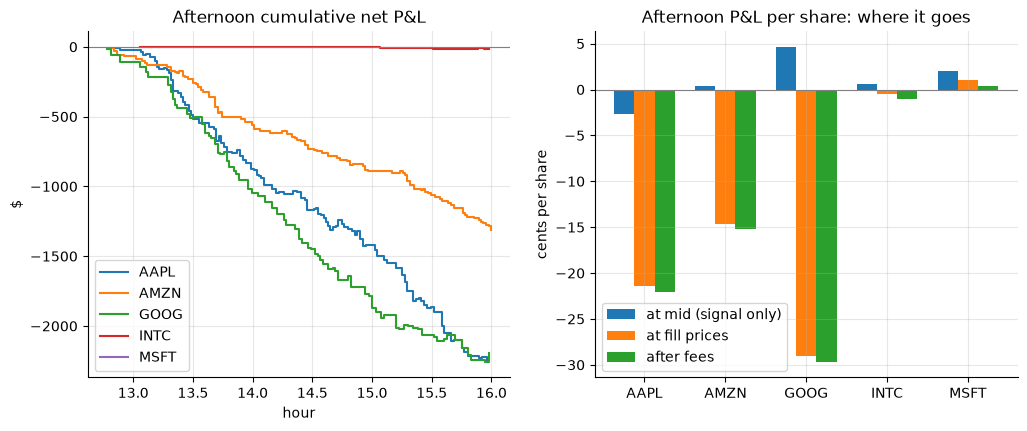

In [7]:
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.5))
for ticker, trades in curves.items():
    if len(trades):
        left.step(clock(trades["exit_time"]), trades["net"].cumsum(), where="post", label=ticker)
left.axhline(0, color="grey", lw=0.8)
left.set(title="Afternoon cumulative net P&L", xlabel="hour", ylabel="$")
left.legend()

afternoon = pnl.xs("afternoon", level="half")
shares = afternoon["trades"] * 100
x = np.arange(len(afternoon))
for offset, column, label in [(-0.25, "at_mid", "at mid (signal only)"),
                              (0, "gross", "at fill prices"), (0.25, "net", "after fees")]:
    right.bar(x + offset, 100 * afternoon[column] / shares, width=0.25, label=label)
right.axhline(0, color="grey", lw=0.8)
right.set(title="Afternoon P&L per share: where it goes", xticks=x, xticklabels=afternoon.index,
          ylabel="cents per share")
right.legend()
plt.show()

**Reading it.** At mid prices the afternoon trades gain 0.4 to 5 cents per share on AMZN,
GOOG, INTC and MSFT, and lose about 3 on AAPL, where the signal is weakest. Paying the spread
erases all of it. On AAPL, AMZN and GOOG the visible book is thin enough that 100 shares sweep
several levels, costing 15 to 34 cents per share. Tuning mostly picks the longest holding
time because it trades least, not because the signal is better there (section 3 shows it is
weaker). MSFT's afternoon has a single trade.

The result is a correct negative: a real, stable, short-horizon signal that is smaller than the
cost of crossing the spread. Profiting from it would mean posting passive orders and earning
the spread instead, which needs a queue-position model.

Simplifications: the strategy's orders don't change the historical book (no market impact),
latency is fixed, fees are a flat taker fee, and this is one day per stock.